In [38]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import warnings


In [39]:
#loading
data = pd.read_csv("PCOS_processed.csv")

# Display the first few rows
print(data.head())

   PCOS (Y/N)  Age (yrs)  Weight (Kg)  Height(Cm)        BMI  Blood Group  \
0           0         28         44.6       152.0  19.300000           15   
1           0         36         65.0       161.5  24.921163           15   
2           1         33         68.8       165.0  25.270891           11   
3           0         37         65.0       148.0  29.674945           13   
4           0         25         52.0       161.0  20.060954           11   

   Pulse rate(bpm)  RR (breaths/min)  Hb(g/dl)  Cycle(R/I)  ...  Pimples(Y/N)  \
0               78                22     10.48           2  ...             0   
1               74                20     11.70           2  ...             0   
2               72                18     11.80           2  ...             1   
3               72                20     12.00           2  ...             0   
4               72                18     10.00           2  ...             0   

   Fast food (Y/N)  Reg.Exercise(Y/N)  BP _Systoli

PCOS (Y/N)               0
Age (yrs)                0
Weight (Kg)              0
Height(Cm)               0
BMI                      0
Blood Group              0
Pulse rate(bpm)          0
RR (breaths/min)         0
Hb(g/dl)                 0
Cycle(R/I)               0
Cycle length(days)       0
Marriage Status (Yrs)    0
Pregnant(Y/N)            0
No. of aborptions        0
I beta-HCG(mIU/mL)       0
II beta-HCG(mIU/mL)      0
FSH(mIU/mL)              0
LH(mIU/mL)               0
FSH/LH                   0
Hip(inch)                0
Waist(inch)              0
Waist:Hip Ratio          0
TSH (mIU/L)              0
AMH(ng/mL)               0
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          0
Reg.Exercise(Y/N)        0
BP _Systolic (mmHg)      0
BP _Diastolic (mmHg)     0
F

/var/folders/s5/6_34vqsj6j50r1gch4sh_3jr0000gn/T/ipykernel_1630/3652614068.py:9: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot=True, cmap='coolwarm')


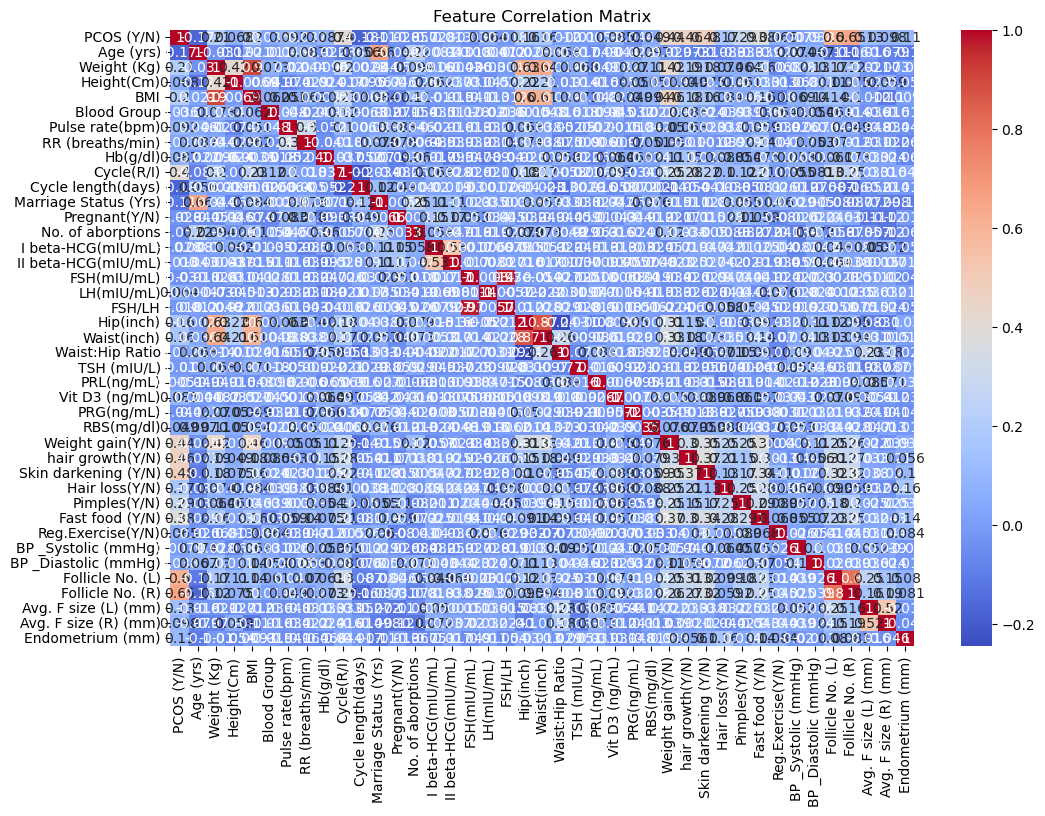

In [40]:
#data exploration and cleaning
print(data.isnull().sum())

# Basic statistics
print(data.describe())

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [41]:
#preprocessing
X = data.drop(columns=['PCOS (Y/N)'])  # Assuming the target column is 'PCOS_Diagnosis'
y = data['PCOS (Y/N)']

# Handle categorical variables if any
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [42]:
#train models
# Define algorithms to test
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    # Print performance
    print(f"{name} - Accuracy: {accuracy:.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")


Logistic Regression - Accuracy: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        77
           1       0.91      0.62      0.74        32

    accuracy                           0.87       109
   macro avg       0.89      0.80      0.83       109
weighted avg       0.88      0.87      0.86       109



Random Forest - Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        77
           1       0.83      0.59      0.69        32

    accuracy                           0.84       109
   macro avg       0.84      0.77      0.79       109
weighted avg       0.84      0.84      0.84       109



Decision Tree - Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.84      0.88        77
           1       0.69      0.84      0.76        32

    accura

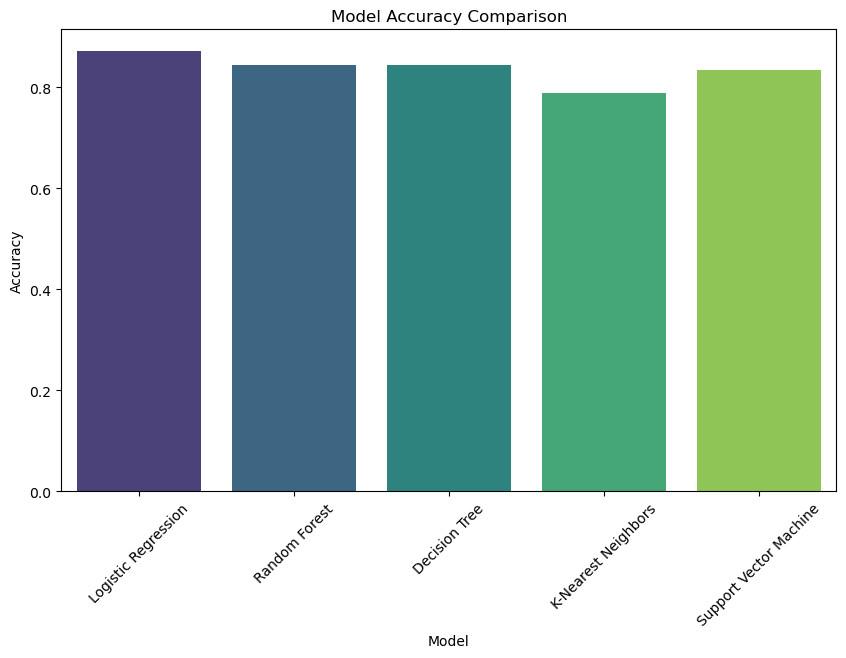

In [43]:
#model comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.show()

In [44]:
#best model
# Find the best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"Best Model: {best_model_name} with Accuracy: {results[best_model_name]:.2f}")

# Save the best model
import joblib
joblib.dump(best_model, f'{best_model_name}_pcos_model.pkl')


Best Model: Logistic Regression with Accuracy: 0.87


['Logistic Regression_pcos_model.pkl']

Logistic Regression - Confusion Matrix:
[[74  3]
 [15 17]]


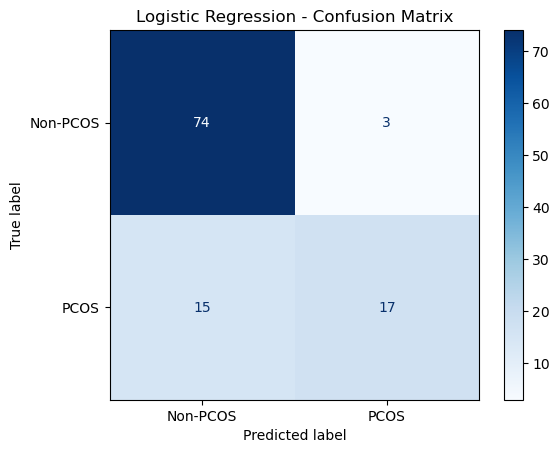

In [45]:
confuse = confusion_matrix(y_test, y_pred)
print(f"{best_model_name} - Confusion Matrix:")
print(confuse)

# Define labels as "Non-PCOS" and "PCOS"
labels = ["Non-PCOS", "PCOS"]

# Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confuse, display_labels=labels)  # Use custom labels
disp.plot(cmap='Blues')
plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()
